# Param Shah
## 240905320
## CSE-D 33
### Lab 4: Polynomial and Multiple Regression

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures 

Sample Questions:\
Polynomial Regression using Scikit-Learn

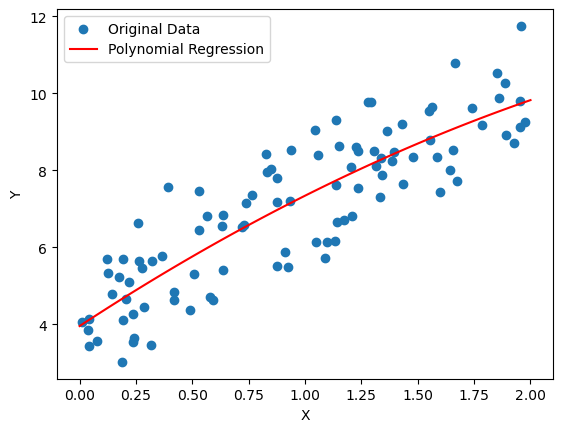

Coefficients:
[[ 0.          3.84100842 -0.45190593]]
Intercept:
[3.95139826]


In [20]:
np.random.seed(0) 
X = 2 * np.random.rand(100, 1) 
Y = 4 + 3 * X + np.random.randn(100, 1) 
degree = 2 
poly_features = PolynomialFeatures(degree=degree) 
X_poly = poly_features.fit_transform(X) 
model = LinearRegression() 
model.fit(X_poly, Y) 
X_new = np.linspace(0, 2, 100).reshape(-1, 1) 
X_new_poly = poly_features.transform(X_new) 
Y_new = model.predict(X_new_poly) 
plt.scatter(X, Y, label='Original Data') 
plt.plot(X_new, Y_new, 'r-', label='Polynomial Regression') 
plt.xlabel('X') 
plt.ylabel('Y') 
plt.legend() 
plt.show() 
coefficients = model.coef_ 
intercept = model.intercept_ 
print("Coefficients:") 
print(coefficients) 
print("Intercept:") 
print(intercept)

Q1) The data set of size n = 15 (Yield data) contains measurements of yield from an experiment done at five different temperature levels. The variables are y = yield and x = temperature in degrees Fahrenheit. \
a. Create a CSV file with sample data. \
b. Write a Python function program to: \
Find the fitted simple linear and polynomial regression equations for the given data. \
c. Compare the coefficients obtained from manually intuitive and matrix  formulation methods with 
your program. \
d. Plot the scatterplot of the raw data and then another scatterplot with lines pertaining to a linear fit and a quadratic fit overlayed. \
e. Compute the error, MSE, and RMSE. 

Simple Linear Regression
Equation: Y = 2.3063063063062974 + 0.006756756756756866 X
Intuitive coefficients: 2.3063063063062974 0.006756756756756866
Matrix coefficients: [2.30630631 0.00675676]
MSE: 0.13270870870870868
RMSE: 0.3642920651190589

Quadratic Polynomial Regression
Equation: Y = 7.960481099654904 + -0.15371134020614519 X + 0.0010756013745702197 X^2
Matrix coefficients: [ 7.96048110e+00 -1.53711340e-01  1.07560137e-03]
MSE: 0.047784650630011485
RMSE: 0.2185970050801508

Error Table
    Temp (X)  Yield (Y)  Linear Prediction  Linear Error  \
0         50        3.3           2.644144      0.655856   
1         50        2.8           2.644144      0.155856   
2         50        2.9           2.644144      0.255856   
3         70        2.3           2.779279     -0.479279   
4         70        2.6           2.779279     -0.179279   
5         70        2.1           2.779279     -0.679279   
6         80        2.5           2.846847     -0.346847   
7         80        2.9  

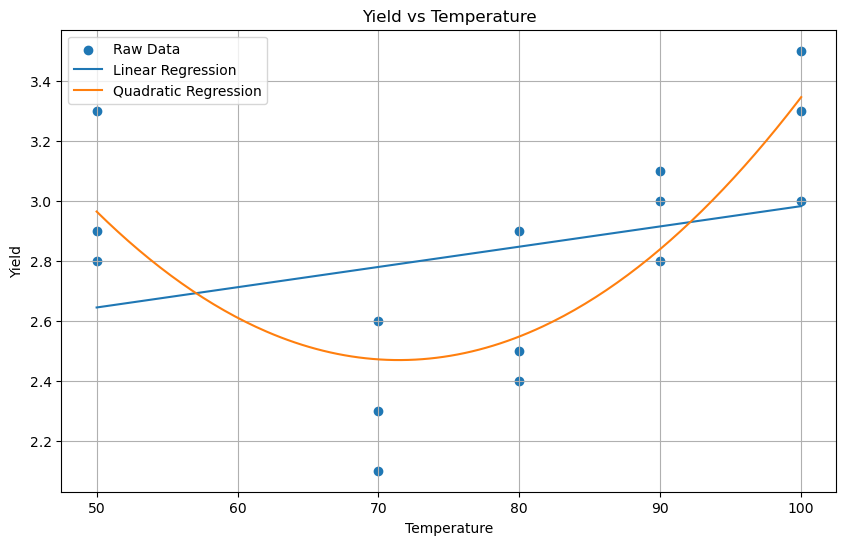

In [21]:
df = pd.read_csv("Yield.csv")

X = df["Temp (X)"].values
Y = df["Yield (Y)"].values
n = len(X)

def calculate_metrics(y, y_pred):
    error = y - y_pred
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    return error, mse, rmse

def simple_linear_regression(x, y):
    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)

    b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    a = (sum_y - b * sum_x) / n

    return a, b

def matrix_linear_regression(x, y):
    A = np.column_stack((np.ones(len(x)), x))
    coefficients = np.linalg.inv(A.T @ A) @ A.T @ y

    return coefficients

def polynomial_regression(x, y, degree=2):
    A = np.column_stack([x ** i for i in range(degree + 1)])
    coefficients = np.linalg.inv(A.T @ A) @ A.T @ y

    return coefficients

a, b = simple_linear_regression(X, Y)

linear_coefficients = matrix_linear_regression(X, Y)

quadratic_coefficients = polynomial_regression(X, Y, 2)

linear_pred = a + b * X

a2, b2, c2 = quadratic_coefficients
quadratic_pred = a2 + b2 * X + c2 * X ** 2

linear_error, linear_mse, linear_rmse = calculate_metrics(Y, linear_pred)
quadratic_error, quadratic_mse, quadratic_rmse = calculate_metrics(Y, quadratic_pred)

print("Simple Linear Regression")
print("Equation: Y =", a, "+", b, "X")
print("Intuitive coefficients:", a, b)
print("Matrix coefficients:", linear_coefficients)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)

print("\nQuadratic Polynomial Regression")
print("Equation: Y =", a2, "+", b2, "X +", c2, "X^2")
print("Matrix coefficients:", quadratic_coefficients)
print("MSE:", quadratic_mse)
print("RMSE:", quadratic_rmse)

result = df.copy()
result["Linear Prediction"] = linear_pred
result["Linear Error"] = linear_error
result["Quadratic Prediction"] = quadratic_pred
result["Quadratic Error"] = quadratic_error

print("\nError Table")
print(result)

x_plot = np.linspace(X.min(), X.max(), 200)

linear_plot = a + b * x_plot
quadratic_plot = a2 + b2 * x_plot + c2 * x_plot ** 2

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label="Raw Data")
plt.plot(x_plot, linear_plot, label="Linear Regression")
plt.plot(x_plot, quadratic_plot, label="Quadratic Regression")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Yield vs Temperature")
plt.legend()
plt.grid()
plt.show()

Q2) When heart muscle is deprived of oxygen, the tissue dies and leads to a heart attack ("myocardial infarction"). Apparently, cooling the heart reduces the size of the heart attack. It is not known, however, whether cooling is only effective if it takes place before the blood, flow to the heart becomes restricted. \
Some researchers (Hale, et al, 1997) hypothesized that cooling the heart would be effective in reducing the size of the heart attack even if it takes place after the blood flow becomes restricted.\
To  investigate  their  hypothesis,  the  researchers  conducted  an experiment  on  32 anesthetized  rabbits that were subjected to a heart attack. The researchers established three experimental groups: \
▪ Rabbits whose hearts were cooled to 6º C within 5 minutes of the blocked artery ("early cooling") \
▪ Rabbits whose hearts were cooled to 6º C within 25 minutes of the blocked artery ("late cooling") \
▪ Rabbits whose hearts were not cooled at all ("no cooling") \
At the end of the experiment, the researchers measured the size of the infarcted (i.e., damaged) area (in grams) in each of the 32 rabbits. But, as you can imagine, there is great variability in the size of hearts. \
The size of a rabbit's infarcted area may be large only because it has a larger heart. Therefore, in order to adjust for differences in heart sizes, the researchers also measured the size of the region at risk for 
infarction (in grams) in each of the 32 rabbits. 

With their measurements in hand, the researchers' primary research question was: Does the mean size 
of  the  infarcted  area  differ  among  the  three treatment  groups  —  no  cooling,  early  cooling,  and  late cooling — when controlling for the size of the region at risk for infarction? \
A regression model that the researchers might use in answering their research question is: \
yi=(β0+β1xi1+β2xi2+β3xi3)+εi \
where: 
▪ yi is the size of the infarcted area (in grams) of rabbit i \
▪ xi1 is the size of the region at risk (in grams) of rabbit i \
▪ xi2 = 1 if early cooling of rabbit i, 0 if not \
▪ xi3 = 1 if late cooling of rabbit i, 0 if not \
and the independent error terms εi follow a normal distribution with mean 0 and equal variance σ2. \
Illustrates the need for being able to "translate" a research question into a statistical procedure. Often, the procedure involves four steps, namely: \
• formulating a multiple regression model \
• determining how the model helps answer the research question \
• checking the model \
• and performing a hypothesis test (or calculating a confidence interval)

a. Create a CSV file with sample data. \
b. Write a Python function program to: \
c. Find the fitted multiple linear regression equation for the given data. \
d. Compare the coefficients obtained manually using intuitive and matrix formulation methods with your program. \
e. Plot the data adorned with the estimated regression equation. \
f. Compute the error, MSE, and RMSE.

In [22]:
def multiple_linear_regression(X, Y):
    XTX = X.T @ X
    XTY = X.T @ Y

    beta = np.linalg.inv(XTX) @ XTY

    return beta


def calculate_metrics(Y, Y_pred):
    error = Y - Y_pred
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)

    return error, mse, rmse


df = pd.read_csv("Infarc_Rate.csv")

Y = df["Infarc"].values

X1 = df["Area"].values
X2 = df["X2"].values
X3 = df["X3"].values

X = np.column_stack((
    np.ones(len(df)),
    X1,
    X2,
    X3
))


beta = multiple_linear_regression(X, Y)

b0 = beta[0]
b1 = beta[1]
b2 = beta[2]
b3 = beta[3]

Y_pred = X @ beta

error, mse, rmse = calculate_metrics(Y, Y_pred)


print("Multiple Linear Regression Equation:")
print(
    f"Y = {b0:.6f} + "
    f"{b1:.6f}X1 + "
    f"{b2:.6f}X2 + "
    f"{b3:.6f}X3"
)

print("\nCoefficients:")
print("b0 =", b0)
print("b1 =", b1)
print("b2 =", b2)
print("b3 =", b3)

print("\nError:")
print(error)

print("\nMSE =", mse)
print("RMSE =", rmse)

Multiple Linear Regression Equation:
Y = -0.134536 + 0.612655X1 + -0.243482X2 + -0.065656X3

Coefficients:
b0 = -0.13453637823601383
b1 = 0.6126549752681978
b2 = -0.2434822333958203
b3 = -0.06565569473887128

Error:
[ 0.04523369 -0.06756281  0.0639186   0.09503275 -0.18270175 -0.0568407
 -0.02948585 -0.0348779   0.08635041  0.08093356  0.17045042  0.02827428
 -0.14037087 -0.17552221 -0.03476291 -0.00401601 -0.11266116 -0.06429391
 -0.00716736 -0.01942046  0.35949019  0.10744774 -0.29409565 -0.1332222
 -0.034716    0.02266365  0.08291675 -0.0469815  -0.10737355  0.00913265
  0.077753    0.31647511]

MSE = 0.017028422624564204
RMSE = 0.13049299837372197


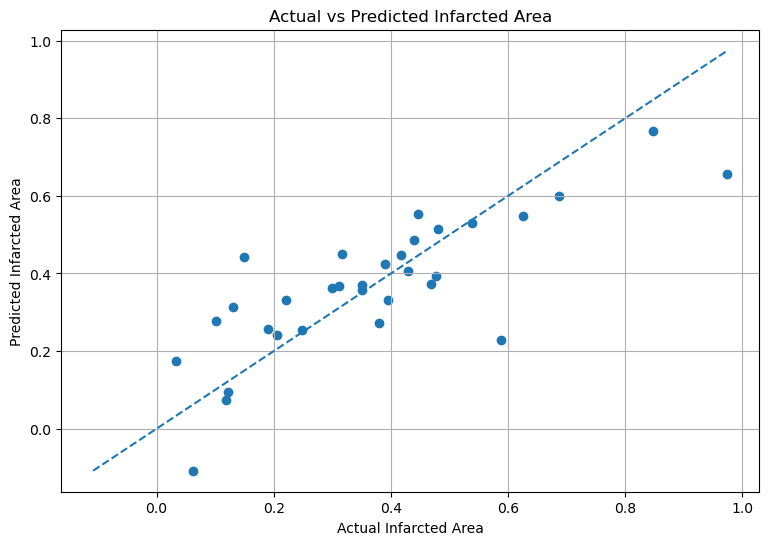

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(Y, Y_pred)

minimum = min(Y.min(), Y_pred.min())
maximum = max(Y.max(), Y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Infarcted Area")
plt.ylabel("Predicted Infarcted Area")
plt.title("Actual vs Predicted Infarcted Area")
plt.grid()
plt.show()